### Exploratory Data Analysis (EDA)

This notebook focuses on understanding the e-commerce dataset before applying machine learning models.
As Member 01, I performed initial data exploration by analyzing the structure, identifying data types, checking for missing values, and visualizing both numerical and categorical features.

Key analyses include distribution of price and quantity, class distribution of delivery status and customer segments, and correlation between numerical variables. The insights obtained from this analysis help guide data preprocessing and model development in later stages of the project.

In [16]:
print(" 3.1 Task: Exploratory Data Analysis (EDA) and Preprocessing Pipeline")

 3.1 Task: Exploratory Data Analysis (EDA) and Preprocessing Pipeline


In [17]:
# Load Cleaned Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../data/ecommerce_data.csv")

df.head()

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

df.info()

df.describe(include="all")

Shape of dataset: (10000, 15)

Columns:
 ['order_id', 'customer_id', 'product_id', 'category', 'price', 'quantity', 'order_date', 'shipping_date', 'delivery_status', 'payment_method', 'device_type', 'channel', 'shipping_address', 'billing_address', 'customer_segment']

Data types:
order_id             object
customer_id           int64
product_id            int64
category             object
price               float64
quantity              int64
order_date           object
shipping_date        object
delivery_status      object
payment_method       object
device_type          object
channel              object
shipping_address     object
billing_address      object
customer_segment     object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-nu

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
count,10000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,NaN,NaN,6,NaN,NaN,365,371,4,5,3,4,10000,10000,3
top,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,NaN,NaN,Home,NaN,NaN,2025-04-01 14:59:58.897063,2024-12-05 14:59:58.897063,Delivered,Apple Pay,Desktop,Social,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
freq,1,NaN,NaN,1713,NaN,NaN,45,45,7047,2068,3383,2566,1,1,5149
mean,NaN,995.292300,504.872400,NaN,252.550681,2.124700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,893.279854,288.281942,NaN,141.394146,1.254315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,1.000000,NaN,5.060000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,182.000000,260.000000,NaN,130.607500,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,754.000000,507.000000,NaN,252.910000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1668.500000,752.000000,NaN,374.917500,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Explanation

At this stage, we examined:

number of rows and columns
data types of each feature
summary statistics
whether columns are numerical, categorical, or datetime-related

This helps us decide which columns need encoding, scaling, date conversion, or removal.

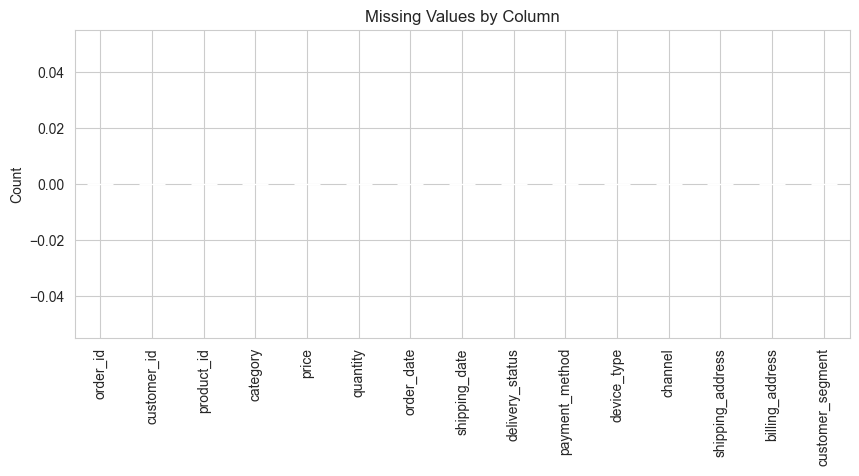

In [18]:
# Missing value analysis

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

plt.figure(figsize=(10, 4))
missing_values.sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.show()

Explanation

This step checks whether the dataset contains missing values. If missing values exist, they must be handled before training models. Since machine learning models usually cannot work directly with missing data, this step is essential for a robust preprocessing workflow.

Dropping unnecessary columns

According to the project brief:

order_id is only an identifier
customer_id is only an identifier
product_id may not be meaningful as a raw number
shipping_address and billing_address are messy text columns and are not directly useful in beginner-level modeling

In [19]:
columns_to_drop = [
    "order_id",
    "customer_id",
    "product_id",
    "shipping_address",
    "billing_address"
]

df = df.drop(columns=columns_to_drop, errors="ignore")
df.head()

,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,customer_segment
0,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,VIP
1,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,Returning
2,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,Returning
3,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,VIP
4,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,VIP


Explanation

These columns were removed because they either:

do not provide useful predictive information in their raw form, or
are too unstructured for beginner-level preprocessing.

This reduces noise and simplifies the pipeline.

In [20]:
# Date feature engineering

if "order_year" not in df.columns:
	df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
	df["shipping_date"] = pd.to_datetime(df["shipping_date"], errors="coerce")

	df["order_year"] = df["order_date"].dt.year
	df["order_month"] = df["order_date"].dt.month
	df["order_day"] = df["order_date"].dt.day
	df["order_dayofweek"] = df["order_date"].dt.dayofweek
	df["order_hour"] = df["order_date"].dt.hour

	df["shipping_year"] = df["shipping_date"].dt.year
	df["shipping_month"] = df["shipping_date"].dt.month
	df["shipping_day"] = df["shipping_date"].dt.day

	df["shipping_time"] = (df["shipping_date"] - df["order_date"]).dt.days

	df = df.drop(columns=["order_date", "shipping_date"], errors="ignore")
	df.head()

Explanation

Machine learning models cannot understand raw datetime values directly. Therefore, we extracted meaningful numerical features such as:

order month
order day
day of week
hour
shipping time in days

These features can help the model learn temporal patterns in buying and shipping behavior.

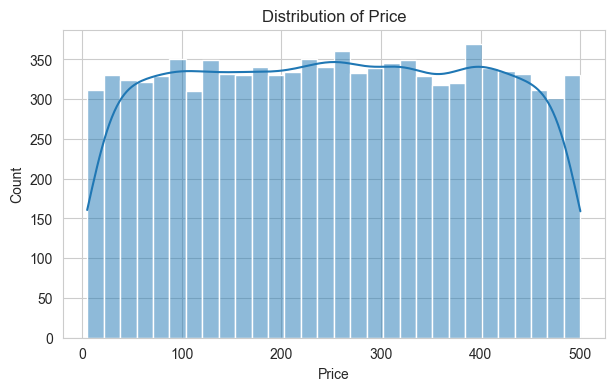

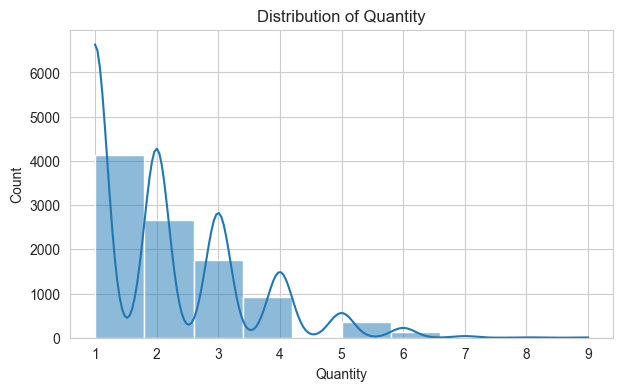

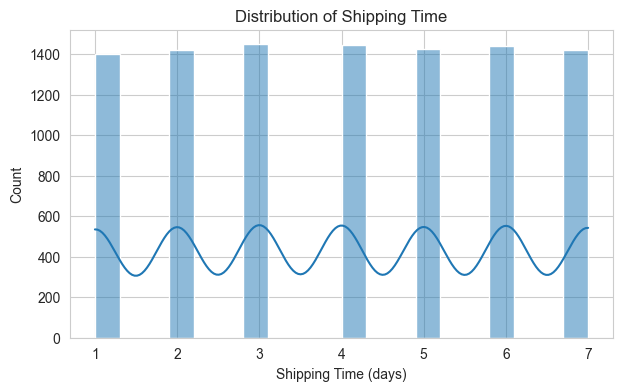

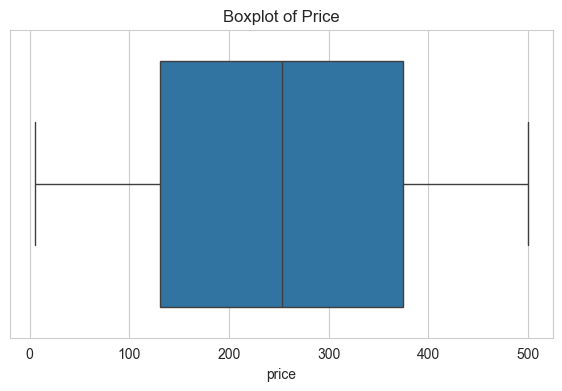

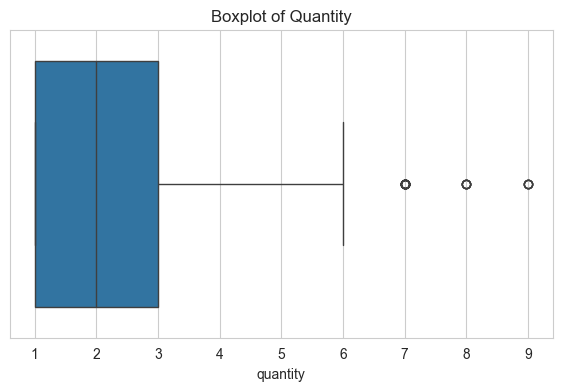

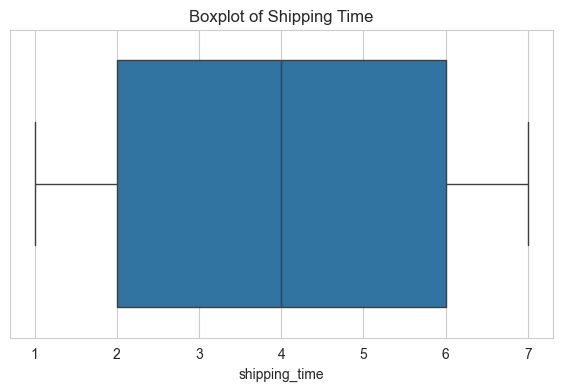

In [21]:
# Analysis of continuous variables

# Price distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.show()

# Quantity distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["quantity"], bins=10, kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.show()

# Shipping time distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["shipping_time"], bins=20, kde=True)
plt.title("Distribution of Shipping Time")
plt.xlabel("Shipping Time (days)")
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x=df["quantity"])
plt.title("Boxplot of Quantity")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x=df["shipping_time"])
plt.title("Boxplot of Shipping Time")
plt.show()

Explanation

These plots help us understand:

whether numerical features are normally distributed
whether skewness exists
whether outliers are present

For example, if price is right-skewed, the model may need scaling so that large values do not dominate training. Outliers also matter because they can affect regression performance and distance-based methods like K-means clustering.

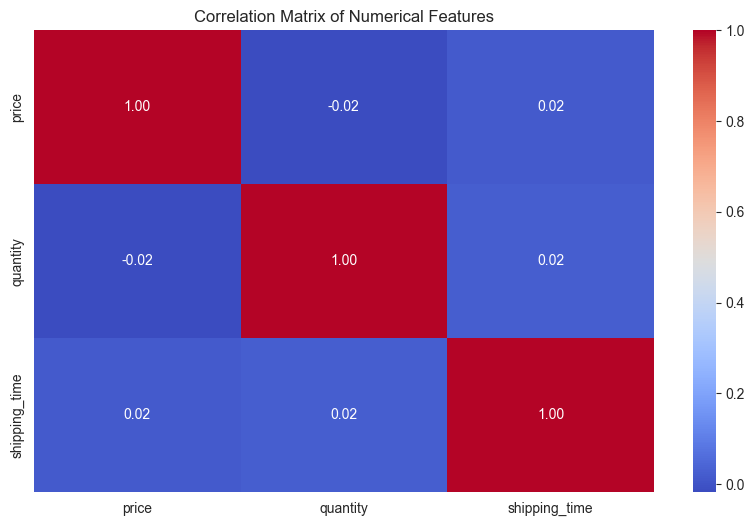

In [22]:
# Correlation analysis

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Explanation

A correlation matrix helps us identify relationships between numerical features. Strong positive or negative correlations can indicate:

useful predictive relationships
possible redundancy between variables

This is important because highly correlated features may not add much new information and can sometimes affect model interpretation.

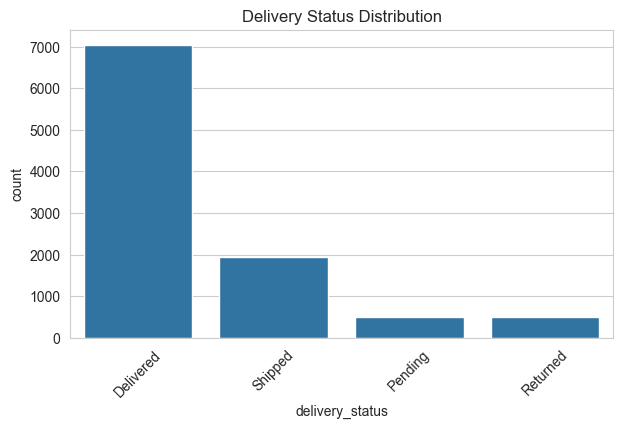

delivery_status
Delivered    70.47
Shipped      19.38
Pending       5.13
Returned      5.02
Name: proportion, dtype: float64


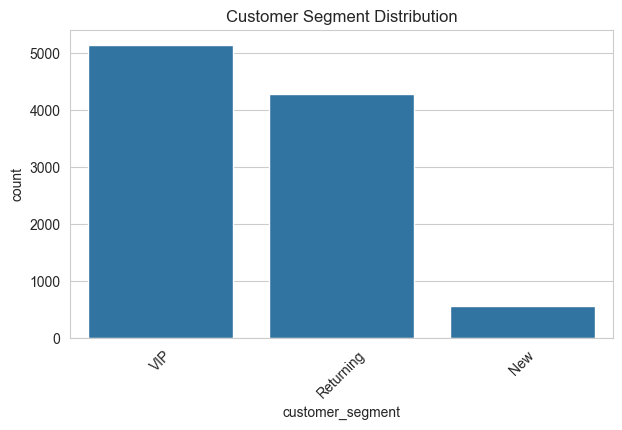

customer_segment
VIP          51.49
Returning    42.85
New           5.66
Name: proportion, dtype: float64


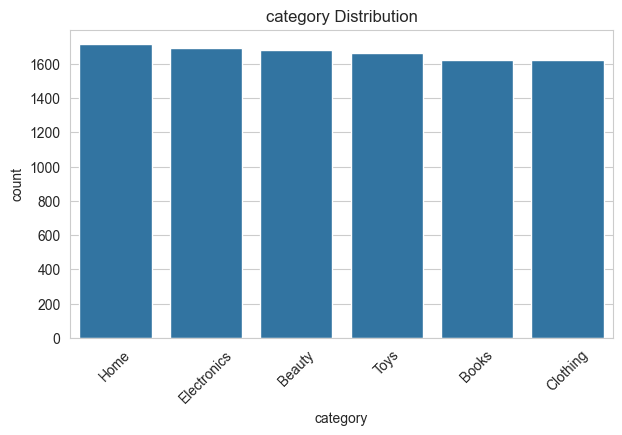

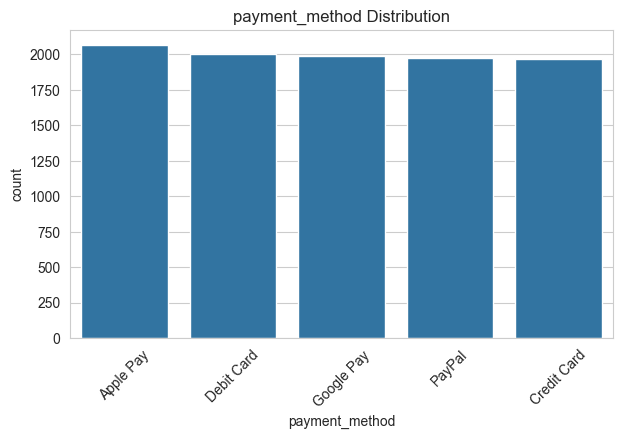

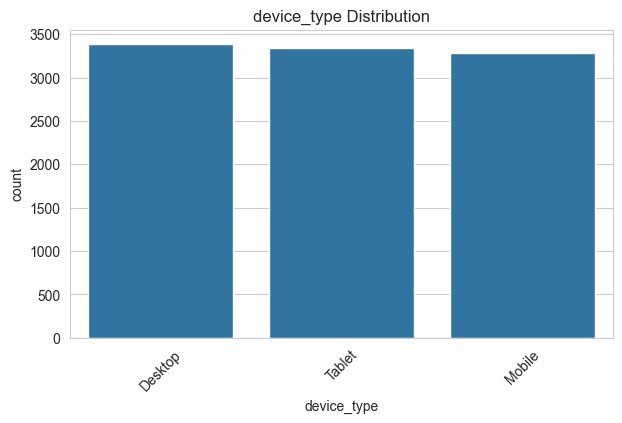

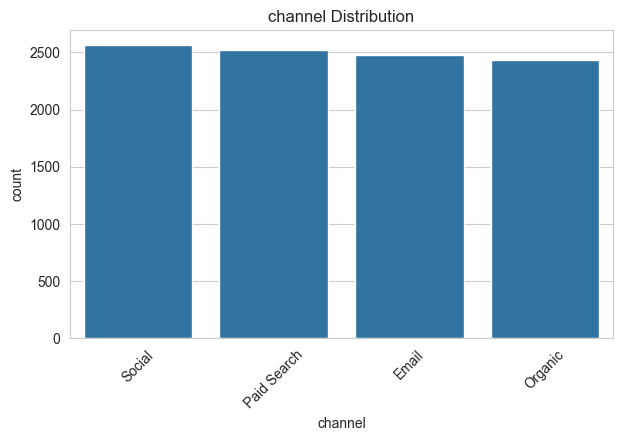

In [23]:
# Categorical variable analysis

# Delivery status distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="delivery_status", data=df, order=df["delivery_status"].value_counts().index)
plt.title("Delivery Status Distribution")
plt.xticks(rotation=45)
plt.show()

print(df["delivery_status"].value_counts(normalize=True) * 100)

# Customer segment distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="customer_segment", data=df, order=df["customer_segment"].value_counts().index)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()

print(df["customer_segment"].value_counts(normalize=True) * 100)

# Other important categorical columns
categorical_columns = ["category", "payment_method", "device_type", "channel"]

for col in categorical_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

    

Explanation

These charts show the frequency of each category. They are useful for identifying class imbalance.

From the project description:

delivery_status is expected to be imbalanced
customer_segment also has fewer VIP customers compared to New and Returning customers

This matters because imbalanced classes can cause classification models to favor majority classes and perform poorly on important minority classes.

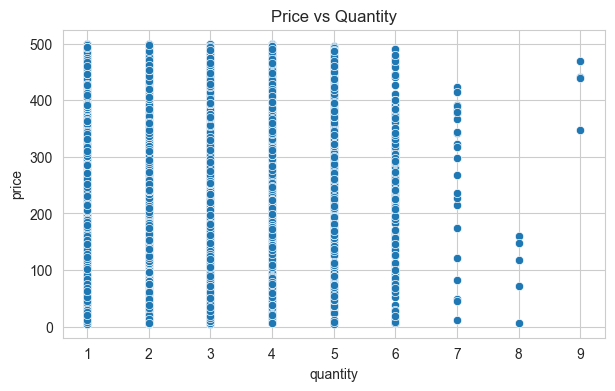

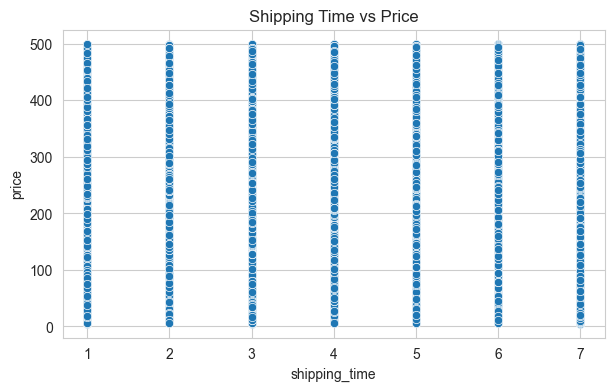

In [24]:
# Relationship analysis between numerical features

plt.figure(figsize=(7, 4))
sns.scatterplot(x="quantity", y="price", data=df)
plt.title("Price vs Quantity")
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(x="shipping_time", y="price", data=df)
plt.title("Shipping Time vs Price")
plt.show()

Explanation

Scatter plots help us visually inspect whether relationships exist between variables. For example:

if price increases with quantity, that indicates a useful predictive pattern
if shipping time relates to price or status, it may help classification or clustering

Key findings from EDA

You can write this in markdown in your notebook:

Key Findings Summary
The dataset contains both numerical and categorical features, so preprocessing must handle both types differently.
The price feature shows some skewness and outliers, meaning scaling is important before modeling.
The delivery_status variable is imbalanced, with one class dominating. This confirms that later classification tasks must consider imbalance-aware evaluation.
The customer_segment variable is also imbalanced, especially with fewer VIP customers.
Temporal information from order_date and shipping_date is useful, so new features such as month, day, hour, and shipping time were extracted.
Raw ID columns and raw address columns are not useful for beginner-level modeling, so they were removed.
Numerical features show some relationships, especially between price-related and quantity-related behavior, which may be useful for prediction.

This summary directly supports later modeling decisions.

Preprocessing pipeline using Scikit-learn

This is the most important missing part from your notebook.

Step 1: Separate features and targets

For Task 3.1, we prepare the feature matrix. Later tasks will use different targets such as:

price for regression
delivery_status for classification
customer_segment for classification

For now, we prepare reusable preprocessing on the input features.

In [25]:
X = df.drop(columns=["price", "delivery_status", "customer_segment"], errors="ignore")
X.head()

,category,quantity,payment_method,device_type,channel,order_year,order_month,order_day,order_dayofweek,order_hour,shipping_year,shipping_month,shipping_day,shipping_time
0,Books,4,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,27,7
1,Electronics,3,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,22,2
2,Beauty,2,Credit Card,Mobile,Email,2024,4,20,5,14,2024,4,27,7
3,Home,3,PayPal,Tablet,Social,2024,4,20,5,14,2024,4,24,4
4,Clothing,1,PayPal,Tablet,Organic,2024,4,20,5,14,2024,4,25,5


Explanation

We remove target columns from the feature set because targets should not be preprocessed as ordinary input features.

In [26]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
# numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()


print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


# Build preprocessing transformers
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

Categorical columns: ['category', 'payment_method', 'device_type', 'channel']
Numerical columns: ['quantity', 'order_year', 'order_month', 'order_day', 'order_dayofweek', 'order_hour', 'shipping_year', 'shipping_month', 'shipping_day', 'shipping_time']


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Explanation

This preprocessing pipeline does the following:

fills missing numerical values using the median
scales numerical features using StandardScaler
fills missing categorical values using the most frequent category
converts categorical values into one-hot encoded columns

This is exactly what the assignment expects: a modular and reusable preprocessing workflow.

In [27]:
# Test the preprocessing pipeline

X_processed = preprocessor.fit_transform(X)
print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (10000, 28)


Explanation

This confirms that the pipeline works correctly and transforms the dataset into a machine-learning-ready numerical format.

In [28]:
# Save cleaned dataset and preprocessing object

import joblib

df.to_csv("../data/cleaned_data.csv", index=False)
joblib.dump(preprocessor, "../artifacts/preprocessor.joblib")

['../artifacts/preprocessor.joblib']